<a href="https://colab.research.google.com/github/Nilaav/Book_Popularity_prediction/blob/main/book_popularity_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas requests tqdm

In [2]:
import requests
import pandas as pd
from tqdm import tqdm
import time

In [3]:
books_data = []

In [4]:
queries = [

    "Indian novels",

    "Indian fiction",

    "Indian literature",

    "Malayalam novels",

    "Malayalam literature",

    "Kerala authors",

    "Indian mythology books",

    "Indian historical novels",

    "Indian romance novels",

    "Indian thriller novels",

    "Indian educational books",

    "Indian biographies",

    "Indian children books",

    "DC Books Kerala",

    "Mathrubhumi books",

    "Current Books Kerala",

    "MT Vasudevan Nair books",

    "Vaikom Muhammad Basheer books",

    "Madhavikutty books",

    "O V Vijayan books"
]

In [5]:
for query in queries:

    print(f"\nCollecting books for: {query}")

    for start_index in tqdm(range(0, 1000, 40)):

        url = f"https://www.googleapis.com/books/v1/volumes?q={query}&startIndex={start_index}&maxResults=40"

        response = requests.get(url)

        if response.status_code != 200:
            continue

        data = response.json()

        items = data.get("items", [])

        for item in items:

            volume_info = item.get("volumeInfo", {})
            sale_info = item.get("saleInfo", {})

            book = {

                "title": volume_info.get("title"),

                "authors": ", ".join(
                    volume_info.get("authors", [])
                ),

                "publisher": volume_info.get("publisher"),

                "publishedDate": volume_info.get("publishedDate"),

                "description": volume_info.get("description"),

                "genre": ", ".join(
                    volume_info.get("categories", [])
                ),

                "pageCount": volume_info.get("pageCount"),

                "averageRating": volume_info.get("averageRating"),

                "review_count": volume_info.get("ratingsCount"),

                "language": volume_info.get("language"),

                "previewLink": volume_info.get("previewLink"),

                "infoLink": volume_info.get("infoLink"),

                "country": sale_info.get("country"),

                "saleability": sale_info.get("saleability")
            }

            # PRICE

            if "listPrice" in sale_info:

                book["price"] = sale_info["listPrice"].get(
                    "amount"
                )

                book["currency"] = sale_info["listPrice"].get(
                    "currencyCode"
                )

            else:

                book["price"] = None

                book["currency"] = None

            books_data.append(book)

        time.sleep(1)

100%|██████████| 25/25 [00:48<00:00,  1.92s/it]


100%|██████████| 25/25 [00:51<00:00,  2.07s/it]


100%|██████████| 25/25 [00:49<00:00,  1.99s/it]


100%|██████████| 25/25 [00:46<00:00,  1.85s/it]


100%|██████████| 25/25 [00:49<00:00,  1.97s/it]


...

100%|██████████| 25/25 [00:45<00:00,  1.80s/it]


100%|██████████| 25/25 [00:36<00:00,  1.46s/it]


100%|██████████| 25/25 [00:35<00:00,  1.40s/it]


100%|██████████| 25/25 [00:36<00:00,  1.45s/it]


100%|██████████| 25/25 [00:40<00:00,  1.63s/it]


In [6]:
df = pd.DataFrame(books_data)

In [7]:
df.drop_duplicates(
    subset=["title", "authors"],
    inplace=True
)

In [8]:
print(df.shape)

(2398, 16)


In [9]:
columns_needed = [

    "title",

    "authors",

    "publisher",

    "publishedDate",

    "description",

    "genre",

    "pageCount",

    "averageRating",

    "review_count",

    "price",

    "currency",

    "language"
]

df = df[columns_needed]

In [10]:
numeric_cols = [

    "pageCount",

    "averageRating",

    "review_count",

    "price"
]

for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [11]:
df[numeric_cols] = df[numeric_cols].fillna(0)

df.fillna("Unknown", inplace=True)

In [12]:
df["popularity_score"] = (
    df["averageRating"].fillna(0) *
    df["review_count"].fillna(0)
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2398 entries, 0 to 2919
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             2398 non-null   object 
 1   authors           2398 non-null   object 
 2   publisher         2398 non-null   object 
 3   publishedDate     2398 non-null   object 
 4   description       2398 non-null   object 
 5   genre             2398 non-null   object 
 6   pageCount         2398 non-null   float64
 7   averageRating     2398 non-null   float64
 8   review_count      2398 non-null   float64
 9   price             2398 non-null   float64
 10  currency          2398 non-null   object 
 11  language          2398 non-null   object 
 12  popularity_score  2398 non-null   float64
dtypes: float64(5), object(8)
memory usage: 262.3+ KB


In [14]:
df.head()

,title,authors,publisher,publishedDate,description,genre,pageCount,averageRating,review_count,price,currency,language,popularity_score
0,The Indian Novel with a Social Purpose,"K. Venkata Reddy, P. Bayapa Reddy",Atlantic Publishers & Dist,1999,The Present Book Seeks To Bring Out The Contou...,Indic fiction (English),252.0,0.0,0.0,0.00,Unknown,en,0.0
1,A Companion to Indian Fiction in English,Pier Paolo Piciucco,Atlantic Publishers & Dist,2004,After The Pioneer Works By Scholars Such As Na...,Indic fiction (English),454.0,0.0,0.0,0.00,Unknown,en,0.0
2,A History of the Indian Novel in English,Ulka Anjaria,Cambridge University Press,2015-07-08,A History of the Indian Novel in English trace...,Literary Criticism,449.0,0.0,0.0,151.00,USD,en,0.0
3,An Annotated Bibliography of Indian English Fi...,,Atlantic Publishers & Dist,2001,Endeavouring To Accomplish An Intract-Able Tig...,Anglo-Indian fiction,492.0,5.0,1.0,0.00,Unknown,en,5.0
4,Ecofeminism and the Indian Novel,Sangita Patil,Routledge,2019-07-08,Ecofeminism and the Indian Novel tests the the...,Literary Criticism,161.0,0.0,0.0,59.99,USD,en,0.0


In [15]:
df.to_csv(
    "book_popularity_dataset.csv",
    index=False
)

In [16]:
from google.colab import files

files.download(
    "book_popularity_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
print(df.shape)

(2398, 13)


In [18]:
df.head()

,title,authors,publisher,publishedDate,description,genre,pageCount,averageRating,review_count,price,currency,language,popularity_score
0,The Indian Novel with a Social Purpose,"K. Venkata Reddy, P. Bayapa Reddy",Atlantic Publishers & Dist,1999,The Present Book Seeks To Bring Out The Contou...,Indic fiction (English),252.0,0.0,0.0,0.00,Unknown,en,0.0
1,A Companion to Indian Fiction in English,Pier Paolo Piciucco,Atlantic Publishers & Dist,2004,After The Pioneer Works By Scholars Such As Na...,Indic fiction (English),454.0,0.0,0.0,0.00,Unknown,en,0.0
2,A History of the Indian Novel in English,Ulka Anjaria,Cambridge University Press,2015-07-08,A History of the Indian Novel in English trace...,Literary Criticism,449.0,0.0,0.0,151.00,USD,en,0.0
3,An Annotated Bibliography of Indian English Fi...,,Atlantic Publishers & Dist,2001,Endeavouring To Accomplish An Intract-Able Tig...,Anglo-Indian fiction,492.0,5.0,1.0,0.00,Unknown,en,5.0
4,Ecofeminism and the Indian Novel,Sangita Patil,Routledge,2019-07-08,Ecofeminism and the Indian Novel tests the the...,Literary Criticism,161.0,0.0,0.0,59.99,USD,en,0.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2398 entries, 0 to 2919
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             2398 non-null   object 
 1   authors           2398 non-null   object 
 2   publisher         2398 non-null   object 
 3   publishedDate     2398 non-null   object 
 4   description       2398 non-null   object 
 5   genre             2398 non-null   object 
 6   pageCount         2398 non-null   float64
 7   averageRating     2398 non-null   float64
 8   review_count      2398 non-null   float64
 9   price             2398 non-null   float64
 10  currency          2398 non-null   object 
 11  language          2398 non-null   object 
 12  popularity_score  2398 non-null   float64
dtypes: float64(5), object(8)
memory usage: 262.3+ KB


In [20]:
df.describe()

,pageCount,averageRating,review_count,price,popularity_score
count,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000
mean,464.723937,0.116972,0.042118,1.713991,0.175771
std,751.068632,0.716030,0.380340,11.656285,1.648397
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,170.000000,0.000000,0.000000,0.000000,0.000000
50%,338.000000,0.000000,0.000000,0.000000,0.000000
75%,604.000000,0.000000,0.000000,0.000000,0.000000
max,18517.000000,5.000000,14.000000,204.990000,63.000000


In [21]:
df.isnull().sum()

,0
title,0
authors,0
publisher,0
publishedDate,0
description,0
genre,0
pageCount,0
averageRating,0
review_count,0
price,0


In [22]:
import matplotlib.pyplot as plt

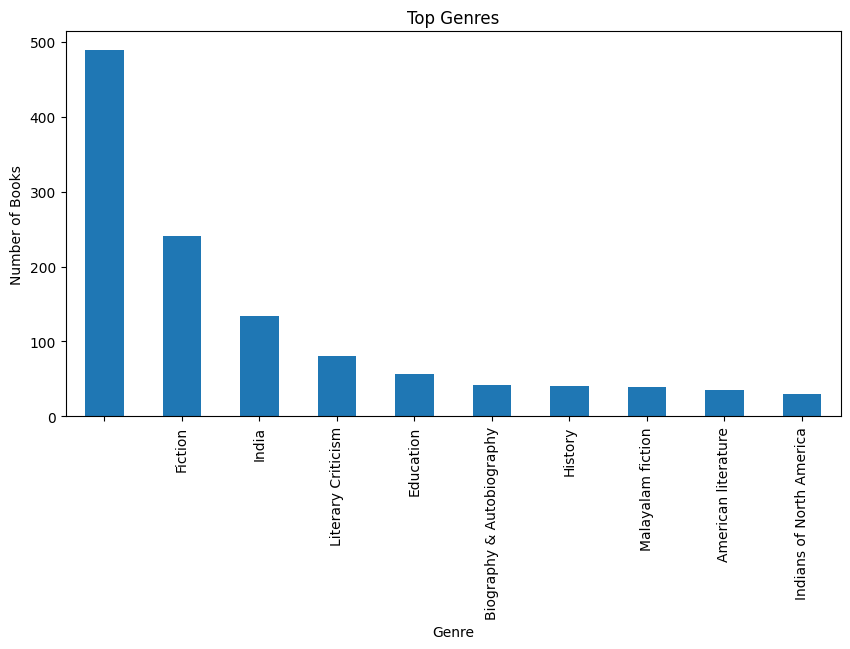

In [23]:
top_genres = df["genre"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_genres.plot(kind="bar")

plt.title("Top Genres")

plt.xlabel("Genre")

plt.ylabel("Number of Books")

plt.show()

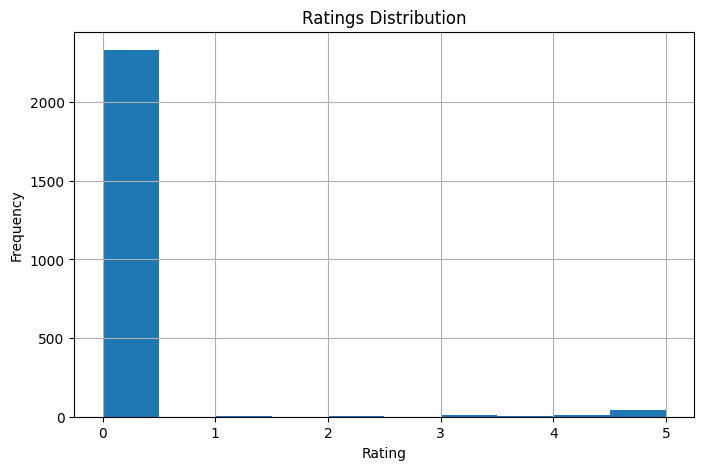

In [24]:
df["averageRating"] = pd.to_numeric(
    df["averageRating"],
    errors="coerce"
)

plt.figure(figsize=(8,5))

df["averageRating"].hist()

plt.title("Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

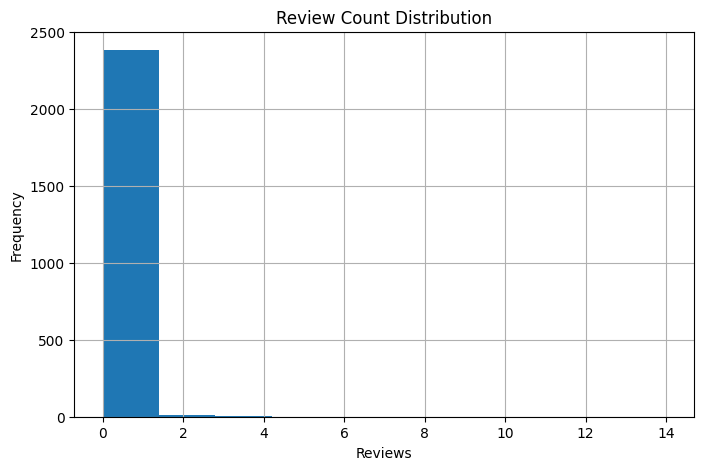

In [25]:
df["review_count"] = pd.to_numeric(
    df["review_count"],
    errors="coerce"
)

plt.figure(figsize=(8,5))

df["review_count"].hist()

plt.title("Review Count Distribution")

plt.xlabel("Reviews")

plt.ylabel("Frequency")

plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
le = LabelEncoder()

df["genre_encoded"] = le.fit_transform(
    df["genre"].astype(str)
)

df["review_density"] = (
    df["review_count"] /
    df["pageCount"]
)

df["price_category"] = pd.cut(
    df["price"],
    bins=[0,200,500,1000,5000],
    labels=["Low","Medium","High","Premium"]
)


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [29]:
features = [
    "pageCount",
    "averageRating",
    "review_count",
    "genre_encoded"
]

X = df[features].fillna(0)

y = df["popularity_score"].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.03046875


In [30]:
import joblib

In [31]:
joblib.dump(
    model,
    "book_popularity_model.pkl"
)

['book_popularity_model.pkl']

# Problem Understanding

The project aims to build a Book Popularity Prediction System using machine learning. The system analyzes book metadata such as genre, ratings, reviews, page count, language, and price to predict the popularity of books. The dataset is collected from the Google Books API and contains a minimum of 2000 books with at least 10 metadata features.

# Success Metric Definition

The project will be considered successful if:

* The dataset contains at least 2000 books and 10+ columns.
* EDA provides meaningful insights through charts and analysis.
* The machine learning model predicts popularity effectively.
* Model performance is evaluated using Mean Absolute Error (MAE), where lower MAE indicates better accuracy.